# 01 Hybrid Late-Fusion Ensemble

## Objective
Build a strong non-generative document classifier for five classes (`invoice`, `form`, `resume`, `email`, `budget`) by combining three classical branches:

1. OCR text branch (TF-IDF + calibrated Linear SVM)
2. Layout branch (engineered OCR geometry features + tree ensemble)
3. Visual handcrafted branch (HOG + LBP + projection features)

The notebook enforces clean train/validation/test discipline:
- branch models are fitted on **train only**;
- fusion weights and stacking design are chosen on **validation only**;
- **test** is held out for final reporting only.

Artifacts are saved under `models/`, `outputs/predictions/`, `reports/figures/`, and `reports/tables/`.

In [4]:
from __future__ import annotations

import sys
import time
from pathlib import Path
from typing import Dict, List, Sequence, Tuple

# Make `src` importable whether kernel cwd is repo root or notebooks/.
_cwd = Path.cwd().resolve()
_candidate_roots = [_cwd, _cwd.parent]
for _root in _candidate_roots:
    if (_root / "src").exists() and str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
        break

import joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from src.config import ProjectConfig
from src.evaluation import (
    compute_metrics,
    confusion_matrix_df,
    classification_report_df,
    metrics_dict_to_frame,
    plot_confusion_matrix,
)
from src.layout_features import build_layout_feature_table
from src.models_fusion import (
    TextBranchConfig,
    fit_layout_preprocessor,
    fit_stacking_meta_classifier,
    fit_text_vectorizers,
    fit_calibrated_linear_svm,
    get_tree_classifier,
    optimize_fusion_weights,
    predict_proba_robust,
    prediction_table,
    save_artifact,
    stacking_predict_proba,
    transform_dense_features,
    transform_text_features,
    weighted_average_fusion,
)
from src.ocr_engine import OCRConfig, load_ocr_text, ocr_batch
from src.visual_features import VisualFeatureConfig, build_visual_feature_table

In [6]:
PROJECT_ROOT = Path(".").resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH = PROJECT_ROOT / "configs" / "config.yaml"

project_cfg = ProjectConfig.from_yaml(CONFIG_PATH) if CONFIG_PATH.exists() else ProjectConfig()
RANDOM_STATE = int(project_cfg.random_seed)

LABELS = ["invoice", "form", "resume", "email", "budget"]

SPLIT_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_PATH = SPLIT_DIR / "train.csv"
VAL_PATH = SPLIT_DIR / "val.csv"
TEST_PATH = SPLIT_DIR / "test.csv"

OUTPUT_ROOT = PROJECT_ROOT / "outputs" / "predictions" / "hybrid_late_fusion"
REPORT_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / "hybrid_late_fusion"
REPORT_FIG_DIR = PROJECT_ROOT / "reports" / "figures" / "hybrid_late_fusion"
MODEL_DIR = PROJECT_ROOT / "models" / "hybrid_late_fusion"

for p in [OUTPUT_ROOT, REPORT_TABLES_DIR, REPORT_FIG_DIR, MODEL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Random seed: {RANDOM_STATE}")

Project root: /Users/danielaguilar/Desktop/school_folder/Stats/group project/document-classification
Random seed: 42


## Load Split Metadata

This notebook expects split files from dataset preparation:
- `data/processed/train.csv`
- `data/processed/val.csv`
- `data/processed/test.csv`

If any file is missing, run `00_dataset_download_and_preparation.ipynb` first.

In [7]:
for required in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not required.exists():
        raise FileNotFoundError(
            f"Missing split file: {required}. Run notebook 00 first to generate canonical splits."
        )

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

def _normalize_paths(df: pd.DataFrame, base_dir: Path) -> pd.DataFrame:
    out = df.copy()
    if "file_path" not in out.columns:
        raise ValueError("Each split CSV must include a 'file_path' column.")

    def _resolve(p: str) -> str:
        path = Path(str(p))
        if path.is_absolute():
            return str(path)
        return str((base_dir / path).resolve())

    out["file_path"] = out["file_path"].astype(str).map(_resolve)
    return out

train_df = _normalize_paths(train_df, PROJECT_ROOT)
val_df = _normalize_paths(val_df, PROJECT_ROOT)
test_df = _normalize_paths(test_df, PROJECT_ROOT)

for split_name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = [c for c in ["doc_id", "file_path", "class_name"] if c not in df.columns]
    if missing:
        raise ValueError(f"{split_name}.csv is missing required columns: {missing}")
    print(f"{split_name}: {len(df):,} rows")

display(train_df["class_name"].value_counts().rename("train_count").to_frame())
display(val_df["class_name"].value_counts().rename("val_count").to_frame())
display(test_df["class_name"].value_counts().rename("test_count").to_frame())

train: 8,777 rows
val: 1,882 rows
test: 1,881 rows


,train_count
class_name,
resume,1775
email,1761
form,1754
budget,1753
invoice,1734


,val_count
class_name,
resume,381
email,378
form,376
budget,376
invoice,371


,test_count
class_name,
resume,380
email,377
form,376
budget,376
invoice,372


## OCR Cache Assurance (Train/Val/Test)

We reuse OCR caches if present and only run OCR for missing document IDs. This keeps the pipeline reproducible and avoids unnecessary OCR reruns.

In [8]:
ocr_cfg = OCRConfig()
if CONFIG_PATH.exists():
    ocr_cfg = project_cfg.ocr


def ensure_ocr_cache(split_df: pd.DataFrame, split_name: str) -> None:
    missing_rows = []
    for row in split_df.itertuples(index=False):
        doc_id = str(row.doc_id)
        try:
            _ = load_ocr_text(doc_id, cfg=ocr_cfg)
        except Exception:
            missing_rows.append({"doc_id": doc_id, "file_path": row.file_path, "class_name": row.class_name, "split": split_name})

    if not missing_rows:
        print(f"[{split_name}] OCR cache ready for all {len(split_df):,} docs.")
        return

    print(f"[{split_name}] Running OCR for {len(missing_rows):,} missing docs...")
    missing_df = pd.DataFrame(missing_rows)
    run_df = ocr_batch(missing_df, cfg=ocr_cfg, force=False, save_diagnostics=False, show_progress=True)
    failed = run_df[run_df["status"] != "ok"]
    if not failed.empty:
        raise RuntimeError(f"OCR failed for {len(failed)} documents in split '{split_name}'.")


ensure_ocr_cache(train_df, "train")
ensure_ocr_cache(val_df, "val")
ensure_ocr_cache(test_df, "test")


def collect_ocr_text(df: pd.DataFrame) -> List[str]:
    return [load_ocr_text(str(doc_id), cfg=ocr_cfg) for doc_id in df["doc_id"].tolist()]

train_texts = collect_ocr_text(train_df)
val_texts = collect_ocr_text(val_df)
test_texts = collect_ocr_text(test_df)

print("OCR text loaded for all splits.")

[train] OCR cache ready for all 8,777 docs.
[val] OCR cache ready for all 1,882 docs.
[test] OCR cache ready for all 1,881 docs.
OCR text loaded for all splits.


## Build Layout and Visual Features

- Layout features come from OCR geometry/token statistics.
- Visual features use handcrafted descriptors (HOG, LBP, projection profiles, connected-component cues).

All feature transforms are fit using train split only where fitting is required.

In [9]:
layout_train = build_layout_feature_table(train_df, cfg=ocr_cfg, show_progress=True)
layout_val = build_layout_feature_table(val_df, cfg=ocr_cfg, show_progress=True)
layout_test = build_layout_feature_table(test_df, cfg=ocr_cfg, show_progress=True)

vis_cfg = VisualFeatureConfig()
visual_train, visual_train_failed = build_visual_feature_table(train_df, cfg=vis_cfg, show_progress=True)
visual_val, visual_val_failed = build_visual_feature_table(val_df, cfg=vis_cfg, show_progress=True)
visual_test, visual_test_failed = build_visual_feature_table(test_df, cfg=vis_cfg, show_progress=True)

if visual_train_failed or visual_val_failed or visual_test_failed:
    print(
        f"Warning: visual features missing for "
        f"train={len(visual_train_failed)}, val={len(visual_val_failed)}, test={len(visual_test_failed)} docs."
    )

def _merge_dense_features(base_df: pd.DataFrame, feat_df: pd.DataFrame, key: str = "doc_id") -> pd.DataFrame:
    merged = base_df[[key]].merge(feat_df, on=key, how="left")
    feature_cols = [c for c in merged.columns if c != key]
    for c in feature_cols:
        merged[c] = pd.to_numeric(merged[c], errors="coerce")
    return merged

layout_train = _merge_dense_features(train_df, layout_train)
layout_val = _merge_dense_features(val_df, layout_val)
layout_test = _merge_dense_features(test_df, layout_test)

visual_train = _merge_dense_features(train_df, visual_train)
visual_val = _merge_dense_features(val_df, visual_val)
visual_test = _merge_dense_features(test_df, visual_test)

print(f"Layout features: {layout_train.shape[1]-1} columns")
print(f"Visual features: {visual_train.shape[1]-1} columns")

Visual features: 100%|██████████| 1881/1881 [04:01<00:00,  7.79it/s]


Layout features: 66 columns
Visual features: 25714 columns


## Train Branch Models

Each branch is trained independently on train split only, then evaluated on validation and test.

In [10]:
y_train = train_df["class_name"].astype(str).to_numpy()
y_val = val_df["class_name"].astype(str).to_numpy()
y_test = test_df["class_name"].astype(str).to_numpy()

# ---------- Text branch ----------
text_cfg = TextBranchConfig(random_state=RANDOM_STATE)
word_vec, char_vec = fit_text_vectorizers(train_texts, cfg=text_cfg)
X_text_train = transform_text_features(train_texts, word_vec, char_vec)
X_text_val = transform_text_features(val_texts, word_vec, char_vec)
X_text_test = transform_text_features(test_texts, word_vec, char_vec)

text_model = fit_calibrated_linear_svm(
    X_text_train,
    y_train,
    c_value=text_cfg.c_value,
    random_state=RANDOM_STATE,
)
text_val_proba_raw, text_classes = predict_proba_robust(text_model, X_text_val)
text_test_proba_raw, _ = predict_proba_robust(text_model, X_text_test)

# ---------- Layout branch ----------
layout_imputer, layout_scaler, layout_cols = fit_layout_preprocessor(layout_train)
X_layout_train = transform_dense_features(layout_train, layout_cols, layout_imputer, layout_scaler)
X_layout_val = transform_dense_features(layout_val, layout_cols, layout_imputer, layout_scaler)
X_layout_test = transform_dense_features(layout_test, layout_cols, layout_imputer, layout_scaler)

layout_model = get_tree_classifier(random_state=RANDOM_STATE)
layout_model.fit(X_layout_train, y_train)
layout_val_proba_raw, layout_classes = predict_proba_robust(layout_model, X_layout_val)
layout_test_proba_raw, _ = predict_proba_robust(layout_model, X_layout_test)

# ---------- Visual branch ----------
visual_cols = [c for c in visual_train.columns if c != "doc_id"]
visual_imputer = layout_imputer.__class__(strategy="median")
visual_scaler = layout_scaler.__class__(with_mean=True, with_std=True)

X_visual_train = visual_imputer.fit_transform(visual_train[visual_cols])
X_visual_train = visual_scaler.fit_transform(X_visual_train)
X_visual_val = visual_scaler.transform(visual_imputer.transform(visual_val[visual_cols]))
X_visual_test = visual_scaler.transform(visual_imputer.transform(visual_test[visual_cols]))

visual_model = LogisticRegression(
    max_iter=3000,
    solver="saga",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
visual_model.fit(X_visual_train, y_train)
visual_val_proba_raw, visual_classes = predict_proba_robust(visual_model, X_visual_val)
visual_test_proba_raw, _ = predict_proba_robust(visual_model, X_visual_test)

print("Finished branch training and probability generation.")

/Users/danielaguilar/Desktop/school_folder/Stats/group project/document-classification/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Finished branch training and probability generation.


In [11]:
def align_proba(raw: np.ndarray, raw_classes: Sequence[str], labels: Sequence[str]) -> np.ndarray:
    aligned = np.zeros((raw.shape[0], len(labels)), dtype=float)
    class_to_idx = {cls: i for i, cls in enumerate(raw_classes)}
    for j, label in enumerate(labels):
        if label in class_to_idx:
            aligned[:, j] = raw[:, class_to_idx[label]]
    row_sum = aligned.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0.0] = 1.0
    return aligned / row_sum

text_val_proba = align_proba(text_val_proba_raw, text_classes, LABELS)
text_test_proba = align_proba(text_test_proba_raw, text_classes, LABELS)
layout_val_proba = align_proba(layout_val_proba_raw, layout_classes, LABELS)
layout_test_proba = align_proba(layout_test_proba_raw, layout_classes, LABELS)
visual_val_proba = align_proba(visual_val_proba_raw, visual_classes, LABELS)
visual_test_proba = align_proba(visual_test_proba_raw, visual_classes, LABELS)

branch_val_probs = {
    "text": text_val_proba,
    "layout": layout_val_proba,
    "visual": visual_val_proba,
}
branch_test_probs = {
    "text": text_test_proba,
    "layout": layout_test_proba,
    "visual": visual_test_proba,
}

branch_val_pred = {k: np.asarray(LABELS)[np.argmax(v, axis=1)] for k, v in branch_val_probs.items()}
branch_test_pred = {k: np.asarray(LABELS)[np.argmax(v, axis=1)] for k, v in branch_test_probs.items()}

metrics_frames = []
for branch_name in ["text", "layout", "visual"]:
    m_val = compute_metrics(y_val, branch_val_pred[branch_name], labels=LABELS)
    m_test = compute_metrics(y_test, branch_test_pred[branch_name], labels=LABELS)
    metrics_frames.append(metrics_dict_to_frame(m_val, model_name=f"{branch_name}_branch", split="val"))
    metrics_frames.append(metrics_dict_to_frame(m_test, model_name=f"{branch_name}_branch", split="test"))

branch_metrics_df = pd.concat(metrics_frames, ignore_index=True)
display(branch_metrics_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
1,text_branch,test,0.877725,0.878310,0.878681,0.799486,0.836022,0.872881,0.821809,0.986450,0.957895,0.964960,0.949602,0.776382,0.821809,0.799486,0.836022
3,layout_branch,test,0.807549,0.807975,0.808431,0.678322,0.782258,0.771084,0.680851,0.912234,0.902632,0.958791,0.925729,0.736842,0.744681,0.678322,0.782258
5,visual_branch,test,0.765019,0.764168,0.764780,0.655647,0.639785,0.652174,0.678191,0.885714,0.897368,0.941489,0.938992,0.685792,0.667553,0.655647,0.639785
0,text_branch,val,0.876196,0.876570,0.877120,0.769042,0.843666,0.871148,0.827128,0.994609,0.968504,0.959677,0.944444,0.797333,0.795213,0.769042,0.843666
2,layout_branch,val,0.803932,0.805114,0.805771,0.691176,0.760108,0.757660,0.723404,0.939891,0.902887,0.952909,0.910053,0.698454,0.720745,0.691176,0.760108
4,visual_branch,val,0.763018,0.761334,0.762275,0.639665,0.617251,0.648990,0.683511,0.897436,0.918635,0.947090,0.947090,0.672222,0.643617,0.639665,0.617251


## Late Fusion and Ablations

Fusion design is selected on validation set only:
- weighted average fusion with validation grid search
- logistic stacking meta-classifier fit on validation branch outputs

Ablations reported:
- text only
- layout only
- visual only
- text + layout (equal weight)
- all three (optimized weighted average)
- all three (stacking)

In [13]:
import importlib
import src.models_fusion as models_fusion

importlib.reload(models_fusion)

# Rebind only the fixed function used in late-fusion cell
fit_stacking_meta_classifier = models_fusion.fit_stacking_meta_classifier

In [14]:
# Weighted fusion tuned on validation only.
best_weights, best_val_macro_f1 = optimize_fusion_weights(branch_val_probs, y_val, LABELS, step=0.1)
print("Best validation weights:", best_weights)
print("Best validation macro-F1:", round(best_val_macro_f1, 4))

weighted_val_proba = weighted_average_fusion(branch_val_probs, LABELS, best_weights)
weighted_test_proba = weighted_average_fusion(branch_test_probs, LABELS, best_weights)
weighted_val_pred = np.asarray(LABELS)[np.argmax(weighted_val_proba, axis=1)]
weighted_test_pred = np.asarray(LABELS)[np.argmax(weighted_test_proba, axis=1)]

# Stacking meta-classifier fitted on validation probabilities.
stack_meta_model, stack_label_encoder = fit_stacking_meta_classifier(branch_val_probs, y_val, random_state=RANDOM_STATE)
stack_val_proba = stacking_predict_proba(stack_meta_model, stack_label_encoder, branch_val_probs, LABELS)
stack_test_proba = stacking_predict_proba(stack_meta_model, stack_label_encoder, branch_test_probs, LABELS)
stack_val_pred = np.asarray(LABELS)[np.argmax(stack_val_proba, axis=1)]
stack_test_pred = np.asarray(LABELS)[np.argmax(stack_test_proba, axis=1)]

# Additional ablation: text + layout simple average.
text_layout_val_proba = weighted_average_fusion({"text": text_val_proba, "layout": layout_val_proba}, LABELS, {"text": 1.0, "layout": 1.0})
text_layout_test_proba = weighted_average_fusion({"text": text_test_proba, "layout": layout_test_proba}, LABELS, {"text": 1.0, "layout": 1.0})
text_layout_val_pred = np.asarray(LABELS)[np.argmax(text_layout_val_proba, axis=1)]
text_layout_test_pred = np.asarray(LABELS)[np.argmax(text_layout_test_proba, axis=1)]

ablation_defs = {
    "text_only": (branch_val_pred["text"], branch_test_pred["text"]),
    "layout_only": (branch_val_pred["layout"], branch_test_pred["layout"]),
    "visual_only": (branch_val_pred["visual"], branch_test_pred["visual"]),
    "text_plus_layout": (text_layout_val_pred, text_layout_test_pred),
    "all_three_weighted": (weighted_val_pred, weighted_test_pred),
    "all_three_stacking": (stack_val_pred, stack_test_pred),
}

ablation_rows = []
for name, (pred_val, pred_test) in ablation_defs.items():
    ablation_rows.append(metrics_dict_to_frame(compute_metrics(y_val, pred_val, labels=LABELS), name, "val"))
    ablation_rows.append(metrics_dict_to_frame(compute_metrics(y_test, pred_test, labels=LABELS), name, "test"))

ablation_df = pd.concat(ablation_rows, ignore_index=True)
display(ablation_df.sort_values(["split", "macro_f1"], ascending=[True, False]))

Best validation weights: {'layout': 0.4, 'text': 0.5, 'visual': 0.09999999999999998}
Best validation macro-F1: 0.8965


/Users/danielaguilar/Desktop/school_folder/Stats/group project/document-classification/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model_name,split,accuracy,macro_f1,weighted_f1,precision_invoice,recall_invoice,precision_form,recall_form,precision_resume,recall_resume,precision_email,recall_email,precision_budget,recall_budget,invoice_precision,invoice_recall
11,all_three_stacking,test,0.897395,0.897991,0.898281,0.848806,0.860215,0.871585,0.848404,0.991781,0.952632,0.983784,0.965517,0.801489,0.859043,0.848806,0.860215
9,all_three_weighted,test,0.895800,0.896349,0.896659,0.823529,0.865591,0.904899,0.835106,0.989071,0.952632,0.976000,0.970822,0.798507,0.853723,0.823529,0.865591
7,text_plus_layout,test,0.889952,0.890430,0.890748,0.813602,0.868280,0.895954,0.824468,0.989071,0.952632,0.968085,0.965517,0.795455,0.837766,0.813602,0.868280
1,text_only,test,0.877725,0.878310,0.878681,0.799486,0.836022,0.872881,0.821809,0.986450,0.957895,0.964960,0.949602,0.776382,0.821809,0.799486,0.836022
3,layout_only,test,0.807549,0.807975,0.808431,0.678322,0.782258,0.771084,0.680851,0.912234,0.902632,0.958791,0.925729,0.736842,0.744681,0.678322,0.782258
5,visual_only,test,0.765019,0.764168,0.764780,0.655647,0.639785,0.652174,0.678191,0.885714,0.897368,0.941489,0.938992,0.685792,0.667553,0.655647,0.639785
10,all_three_stacking,val,0.899044,0.899305,0.899771,0.823377,0.854447,0.891967,0.856383,0.994624,0.971129,0.983914,0.970899,0.808184,0.840426,0.823377,0.854447
8,all_three_weighted,val,0.895855,0.896451,0.896935,0.798507,0.865229,0.918367,0.837766,0.997297,0.968504,0.978552,0.965608,0.802030,0.840426,0.798507,0.865229
6,text_plus_layout,val,0.891605,0.892199,0.892685,0.789731,0.870620,0.900285,0.840426,0.994595,0.965879,0.981030,0.957672,0.806789,0.821809,0.789731,0.870620
0,text_only,val,0.876196,0.876570,0.877120,0.769042,0.843666,0.871148,0.827128,0.994609,0.968504,0.959677,0.944444,0.797333,0.795213,0.769042,0.843666


## Save Models, Predictions, and Reports

Saved models, predictions, metrics, and confusion matrices.


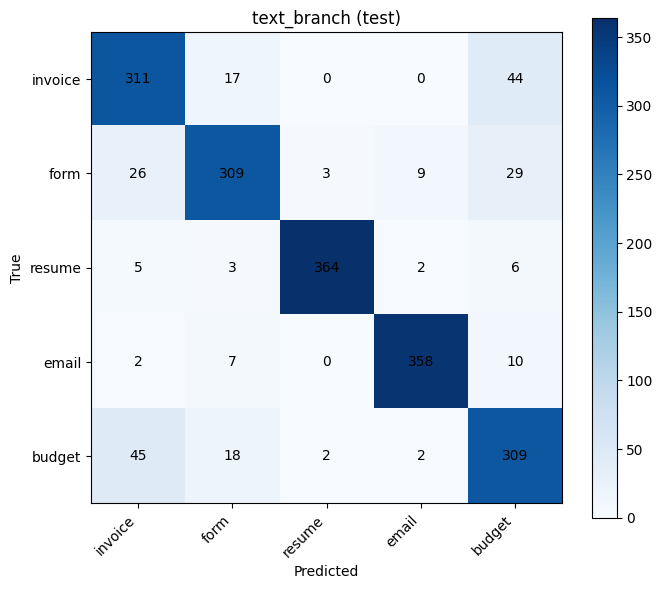

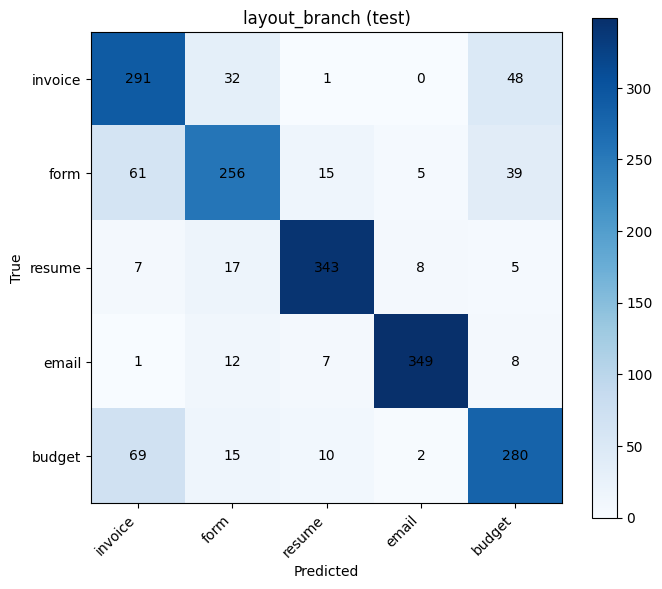

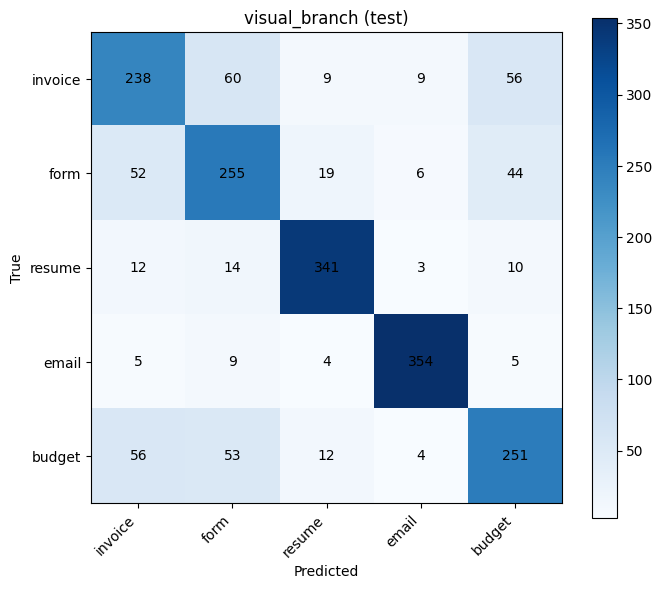

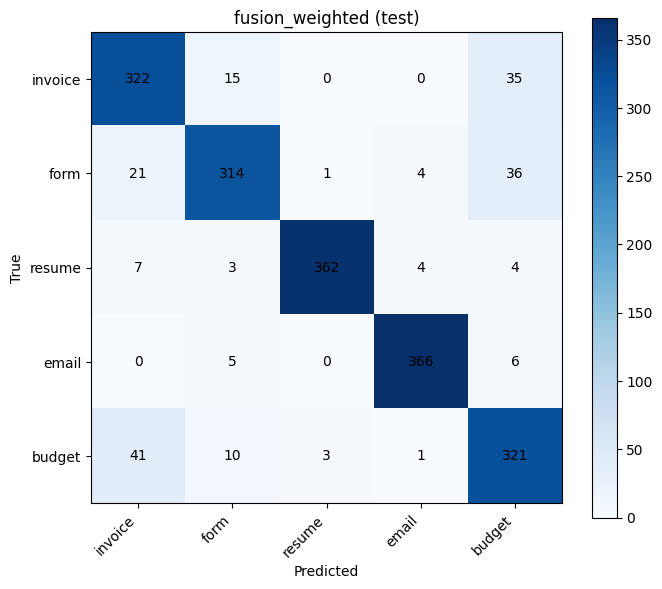

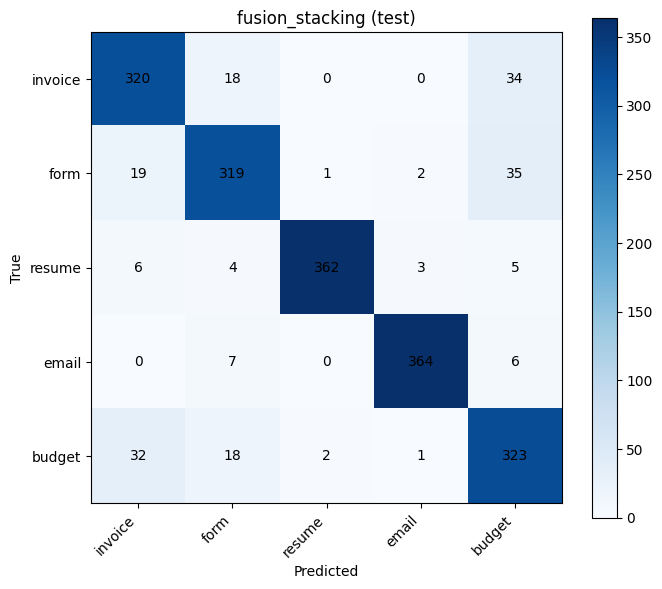

In [15]:
# Save branch objects
save_artifact(word_vec, MODEL_DIR / "text_word_vectorizer.joblib")
save_artifact(char_vec, MODEL_DIR / "text_char_vectorizer.joblib")
save_artifact(text_model, MODEL_DIR / "text_calibrated_linear_svm.joblib")

save_artifact(layout_imputer, MODEL_DIR / "layout_imputer.joblib")
save_artifact(layout_scaler, MODEL_DIR / "layout_scaler.joblib")
save_artifact(layout_cols, MODEL_DIR / "layout_feature_columns.joblib")
save_artifact(layout_model, MODEL_DIR / "layout_model.joblib")

save_artifact(visual_imputer, MODEL_DIR / "visual_imputer.joblib")
save_artifact(visual_scaler, MODEL_DIR / "visual_scaler.joblib")
save_artifact(visual_cols, MODEL_DIR / "visual_feature_columns.joblib")
save_artifact(visual_model, MODEL_DIR / "visual_model.joblib")

save_artifact(best_weights, MODEL_DIR / "fusion_best_weights.joblib")
save_artifact(stack_meta_model, MODEL_DIR / "stacking_meta_model.joblib")
save_artifact(stack_label_encoder, MODEL_DIR / "stacking_label_encoder.joblib")

# Prediction tables
pred_tables = {
    "text_branch_val": prediction_table(val_df["doc_id"], y_val, branch_val_pred["text"], "val", "text_branch", LABELS, text_val_proba),
    "text_branch_test": prediction_table(test_df["doc_id"], y_test, branch_test_pred["text"], "test", "text_branch", LABELS, text_test_proba),
    "layout_branch_val": prediction_table(val_df["doc_id"], y_val, branch_val_pred["layout"], "val", "layout_branch", LABELS, layout_val_proba),
    "layout_branch_test": prediction_table(test_df["doc_id"], y_test, branch_test_pred["layout"], "test", "layout_branch", LABELS, layout_test_proba),
    "visual_branch_val": prediction_table(val_df["doc_id"], y_val, branch_val_pred["visual"], "val", "visual_branch", LABELS, visual_val_proba),
    "visual_branch_test": prediction_table(test_df["doc_id"], y_test, branch_test_pred["visual"], "test", "visual_branch", LABELS, visual_test_proba),
    "fusion_weighted_val": prediction_table(val_df["doc_id"], y_val, weighted_val_pred, "val", "fusion_weighted", LABELS, weighted_val_proba),
    "fusion_weighted_test": prediction_table(test_df["doc_id"], y_test, weighted_test_pred, "test", "fusion_weighted", LABELS, weighted_test_proba),
    "fusion_stacking_val": prediction_table(val_df["doc_id"], y_val, stack_val_pred, "val", "fusion_stacking", LABELS, stack_val_proba),
    "fusion_stacking_test": prediction_table(test_df["doc_id"], y_test, stack_test_pred, "test", "fusion_stacking", LABELS, stack_test_proba),
}

for name, table in pred_tables.items():
    table.to_csv(OUTPUT_ROOT / f"{name}.csv", index=False)

# Metrics and reports
branch_metrics_df.to_csv(REPORT_TABLES_DIR / "branch_metrics.csv", index=False)
ablation_df.to_csv(REPORT_TABLES_DIR / "ablation_metrics.csv", index=False)

for model_name, y_pred in {
    "text_branch": branch_test_pred["text"],
    "layout_branch": branch_test_pred["layout"],
    "visual_branch": branch_test_pred["visual"],
    "fusion_weighted": weighted_test_pred,
    "fusion_stacking": stack_test_pred,
}.items():
    rep = classification_report_df(y_test, y_pred, labels=LABELS)
    rep.to_csv(REPORT_TABLES_DIR / f"classification_report_{model_name}_test.csv")

    cm = confusion_matrix_df(y_test, y_pred, labels=LABELS)
    cm.to_csv(REPORT_TABLES_DIR / f"confusion_matrix_{model_name}_test.csv")
    plot_confusion_matrix(
        cm,
        title=f"{model_name} (test)",
        save_path=REPORT_FIG_DIR / f"confusion_matrix_{model_name}_test.png",
    )

print("Saved models, predictions, metrics, and confusion matrices.")

## Conclusion

This notebook trains and compares three classical branches and two late-fusion strategies under strict split discipline. Use the saved ablation table to select the best candidate for downstream comparison and invoice-gated extraction workflows.